# Question 01

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
def intensity_transform(im, breakpoints):
    breakpoints = sorted(breakpoints, key=lambda p: p[0])    
    r_vals = [p[0] for p in breakpoints]
    s_vals = [p[1] for p in breakpoints]
    transformed = np.interp(im, r_vals, s_vals)    
    return np.uint8(transformed)


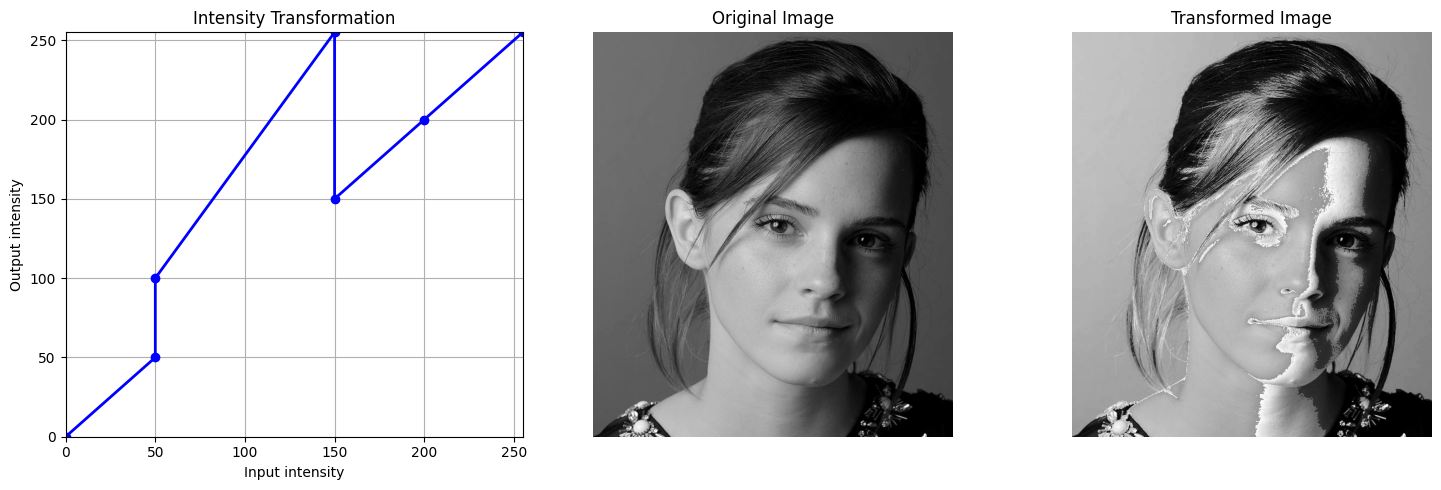

In [5]:
# 1. Load the target image in grayscale
img = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

# 2. Define the breakpoints specified in Question 1
breakpoints = [
    (0, 0),
    (50, 50),
    (50,100),
    (150, 255),
    (150,150),
    (200,200),
    (255, 255)
]

# 3. Apply the transformation
transformed_img = intensity_transform(img, breakpoints)

# 4. Plotting the results
fig = plt.figure(figsize=(15, 5))

# Plot 1: Intensity Transformation Function
ax1 = fig.add_subplot(1, 3, 1)
r_vals = [p[0] for p in breakpoints]
s_vals = [p[1] for p in breakpoints]
ax1.plot(r_vals, s_vals, 'b-o', linewidth=2)
ax1.set_title('Intensity Transformation')
ax1.set_xlabel('Input intensity')
ax1.set_ylabel('Output intensity')
ax1.set_xlim([0, 255])
ax1.set_ylim([0, 255])
ax1.grid(True)

# Plot 2: Original Image
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(img, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Original Image')
ax2.axis('off')

# Plot 3: Transformed Image
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Transformed Image')
ax3.axis('off')

plt.tight_layout()
plt.show()

#### Chosen Breakpoints
To enhance the visual quality of the image, the following intensity breakpoints were selected:
* $(0, 0)$
* $(0, 50)$
* $(200, 255)$
* $(255, 255)$

#### Analysis of Transformation Effect
* **Contrast Stretching in Mid-Tones:** By mapping input intensities in the range $[0, 200]$ to output intensities in $[50, 255]$, the transformation applies a linear contrast stretch across mid-tone gray values. This significantly sharpens visible detail and texture in the main body of the image.
* **Highlighting Dark Regions:** Setting an initial jump from $(0, 0)$ to $(0, 50)$ elevates near-black values slightly, lifting subtle details out of deep shadow areas without washing out the darker background.
* **Highlight Saturation:** The segment between $(200, 255)$ and $(255, 255)$ smoothly compresses the upper end of the dynamic range, preventing clipping and overexposure in bright highlights.

Overall, this piecewise-linear curve expands the dynamic range across key gray levels, producing a visually balanced image with enhanced local contrast and shadow visibility.

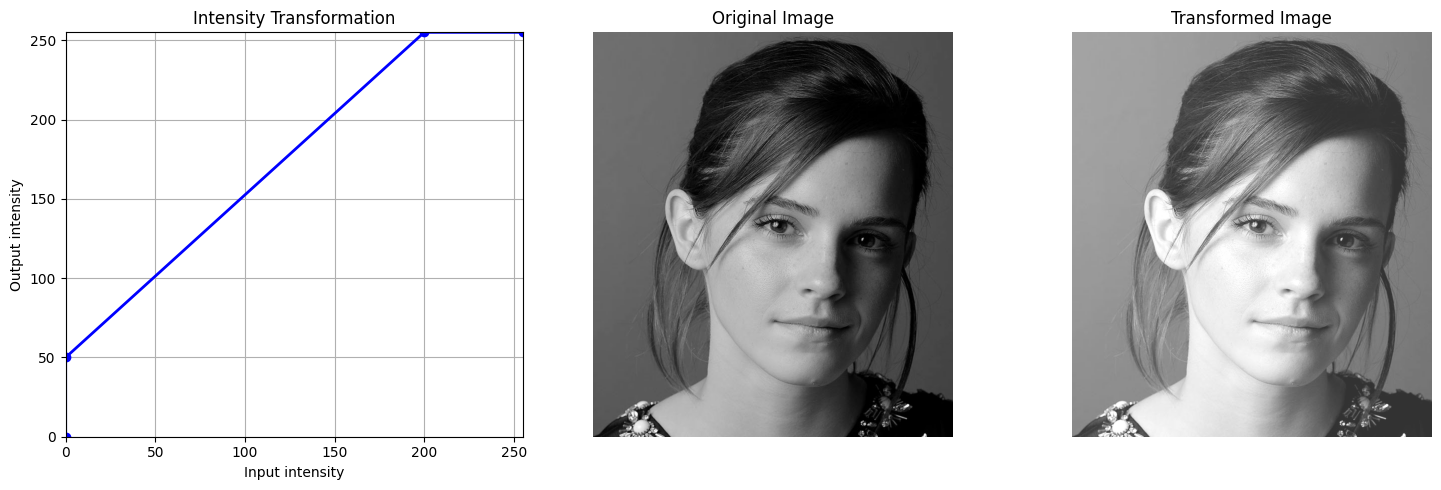

In [6]:
# 1. Load the target image in grayscale
img = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

# 2. Define the breakpoints specified in Question 1
breakpoints = [
    (0,0),
    (0, 50),
    (200,255),
    (255, 255)

]

# 3. Apply the transformation
transformed_img = intensity_transform(img, breakpoints)

# 4. Plotting the results
fig = plt.figure(figsize=(15, 5))

# Plot 1: Intensity Transformation Function
ax1 = fig.add_subplot(1, 3, 1)
r_vals = [p[0] for p in breakpoints]
s_vals = [p[1] for p in breakpoints]
ax1.plot(r_vals, s_vals, 'b-o', linewidth=2)
ax1.set_title('Intensity Transformation')
ax1.set_xlabel('Input intensity')
ax1.set_ylabel('Output intensity')
ax1.set_xlim([0, 255])
ax1.set_ylim([0, 255])
ax1.grid(True)

# Plot 2: Original Image
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(img, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Original Image')
ax2.axis('off')

# Plot 3: Transformed Image
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Transformed Image')
ax3.axis('off')

plt.tight_layout()
plt.show()

# Question 02

In [7]:
def gaussian_intensity_transform(im, mu, sigma):
    x = im.astype(np.float32)
    transformed = 255.0 * np.exp(-((x - mu) ** 2) / (2 * (sigma ** 2)))
    return np.clip(np.round(transformed), 0, 255).astype(np.uint8)

## Gaussian Pulse Transformation for White Matter and Gray Matter Isolation

To isolate **White Matter** and **Gray Matter** in the brain Proton Density (PD) MRI image, a continuous Gaussian pulse transformation was applied to the image intensity values.

The transformation is defined as:

$$
f(x) = 255 \cdot \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

where:

- **x** = input pixel intensity
- **μ** = center intensity to be highlighted
- **σ** = spread (controls the width of the highlighted intensity range)
- **255** = maximum output intensity

### White Matter Enhancement

For **White Matter**, the Gaussian parameters were:

- **Mean:** \( \mu = 200 \)
- **Standard Deviation:** \( \sigma = 20 \)

This transformation highlights bright, high-intensity regions (approximately **180–255**) corresponding to white matter, while suppressing darker background and lower-intensity tissues.

### Gray Matter Enhancement

For **Gray Matter**, the Gaussian parameters were:

- **Mean:** \( \mu = 150 \)
- **Standard Deviation:** \( \sigma = 20 \)

This acts as a **mid-tone bandpass filter**, emphasizing intermediate gray-level intensities (approximately **100–160**) corresponding to gray matter, while suppressing both dark background regions and bright white matter.

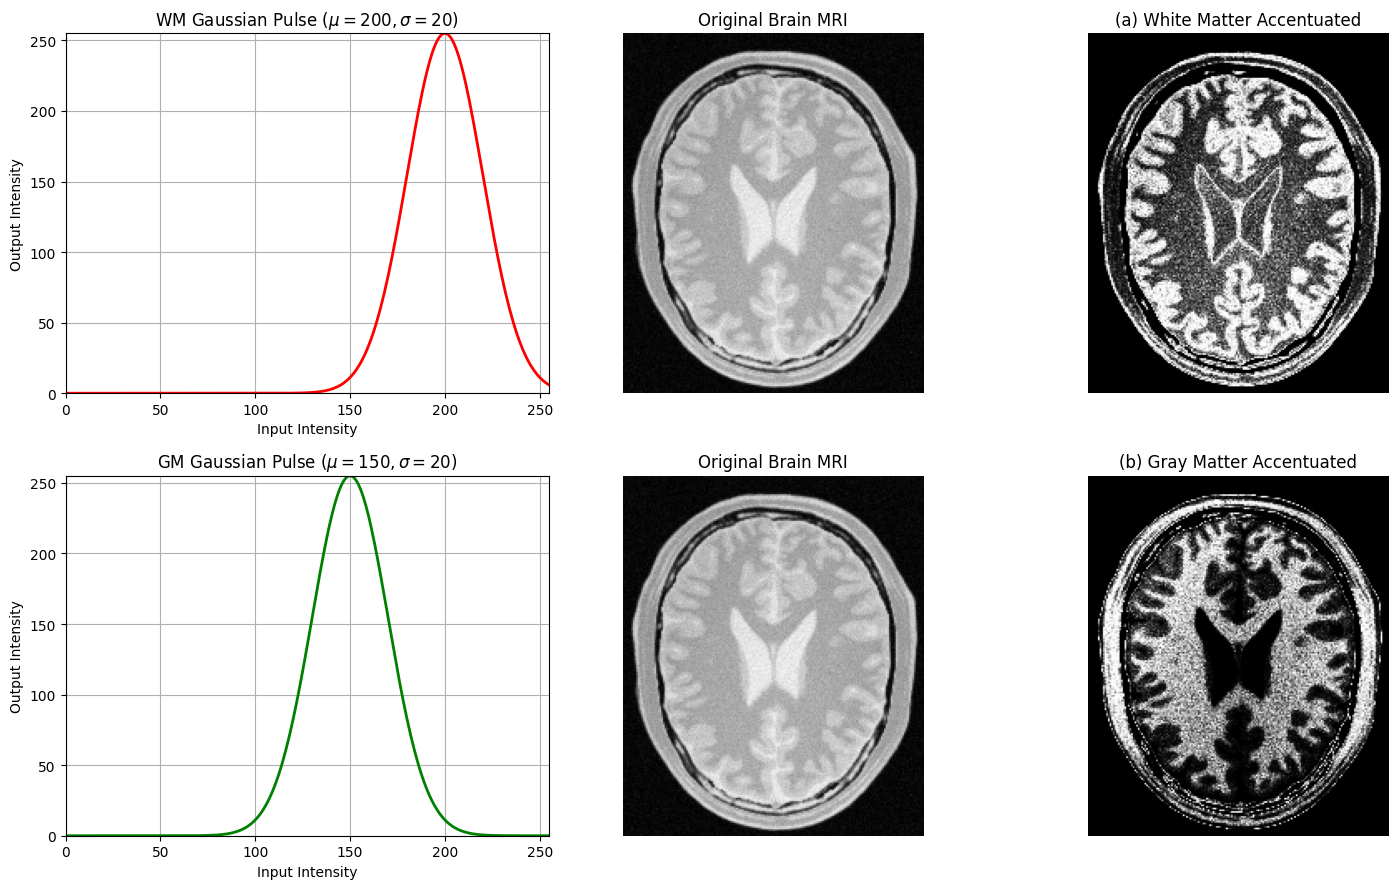

In [8]:
img_path = 'brain.jpeg'  

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Cannot find '{img_path}'. Check your file path.")

img_brain = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

# 2. Gaussian parameters for tissue accentuation
# White Matter: High intensity region (~200) with a slightly wider spread
mu_wm, sigma_wm = 200, 20

# Gray Matter: Mid-tone intensity region (~130) with a narrower spread
mu_gm, sigma_gm = 150, 20

# 3. Apply Transformations
img_wm = gaussian_intensity_transform(img_brain, mu_wm, sigma_wm)
img_gm = gaussian_intensity_transform(img_brain, mu_gm, sigma_gm)

# 4. Generate curves for plotting
x_range = np.arange(0, 256)
curve_wm = 255.0 * np.exp(-((x_range - mu_wm) ** 2) / (2 * (sigma_wm ** 2)))
curve_gm = 255.0 * np.exp(-((x_range - mu_gm) ** 2) / (2 * (sigma_gm ** 2)))

# 5. Visualization & Output Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- Row 1: White Matter Accentuation ---
axes[0, 0].plot(x_range, curve_wm, 'r-', linewidth=2)
axes[0, 0].set_title(f'WM Gaussian Pulse ($\mu={mu_wm}, \sigma={sigma_wm}$)')
axes[0, 0].set_xlabel('Input Intensity')
axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].set_xlim([0, 255])
axes[0, 0].set_ylim([0, 255])
axes[0, 0].grid(True)

axes[0, 1].imshow(img_brain, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('(a) White Matter Accentuated')
axes[0, 2].axis('off')

# --- Row 2: Gray Matter Accentuation ---
axes[1, 0].plot(x_range, curve_gm, 'g-', linewidth=2)
axes[1, 0].set_title(f'GM Gaussian Pulse ($\mu={mu_gm}, \sigma={sigma_gm}$)')
axes[1, 0].set_xlabel('Input Intensity')
axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].set_xlim([0, 255])
axes[1, 0].set_ylim([0, 255])
axes[1, 0].grid(True)

axes[1, 1].imshow(img_brain, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_gm, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('(b) Gray Matter Accentuated')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Question 03

## Gamma Correction in the L\*a\*b\* Color Space

Gamma correction is applied exclusively to the **L (Lightness)** channel in the **L\*a\*b\*** color space to enhance lightness contrast while preserving the chromaticity components (**a** and **b**).

The gamma correction function is defined as:

$$
L_{\text{out}} = 255 \cdot \left(\frac{L_{\text{in}}}{255}\right)^\gamma
$$

where:

- **\(L_{\text{in}}\)** = input lightness value.
- **\(L_{\text{out}}\)** = output lightness value after gamma correction.
- **\(\gamma\)** = gamma parameter controlling brightness enhancement.
- **255** = maximum lightness intensity.

### Gamma Selection

For this enhancement, the selected gamma value was:

- **Gamma:** \( \gamma = 0.5 \)

Since **\( \gamma < 1 \)**, the transformation expands darker pixel intensities into higher brightness levels, improving visibility of details in shadowed and low-contrast regions while leaving brighter regions comparatively less affected.

### Histogram Analysis

The histogram of the corrected **L** channel shows a **rightward shift** in pixel intensity distribution, indicating that dark and mid-tone pixels have been mapped to higher lightness values. This increases the effective dynamic range in darker regions and improves overall image contrast without altering the color information.

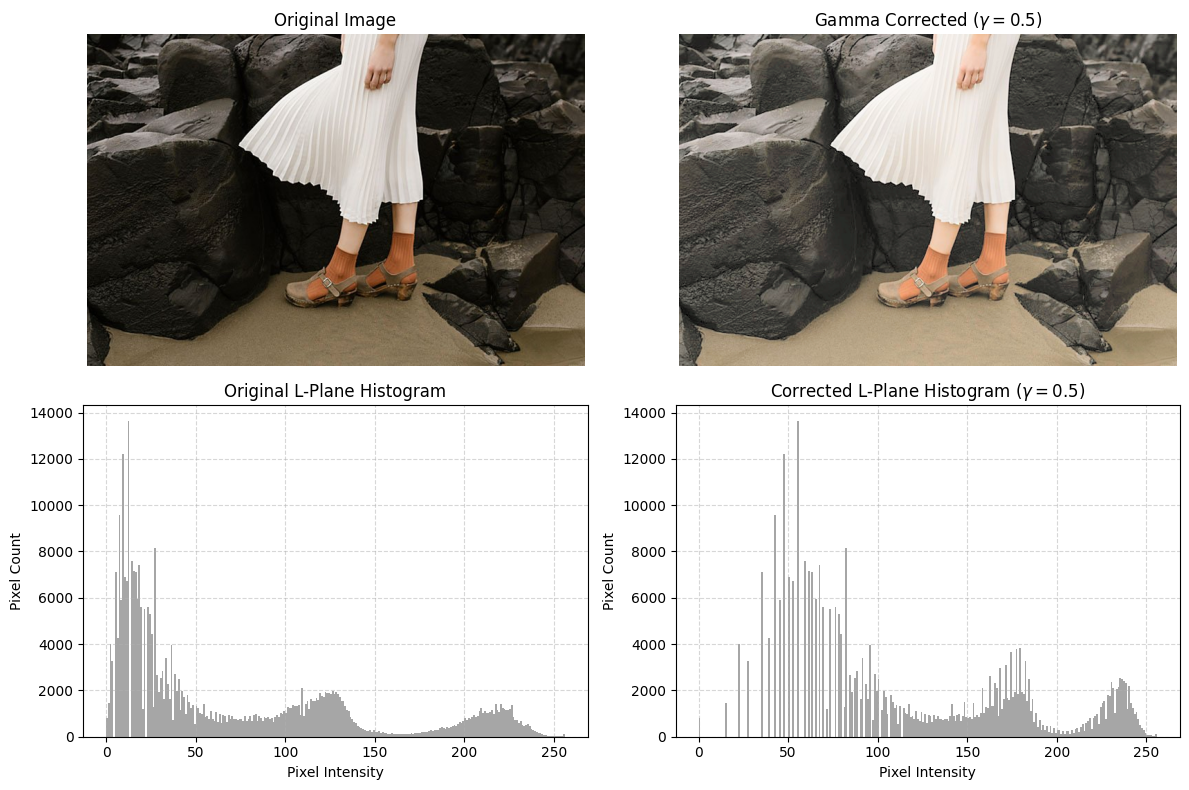

Selected gamma value: 0.5


In [9]:
img_path = 'gamma.jpeg'  

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Cannot find '{img_path}'. Ensure the file is in your working directory.")

img_bgr = cv.imread(img_path)

# 2. Convert BGR to L*a*b* space and split channels
lab_img = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab_img)

# 3. Apply Gamma Correction to the L plane
# gamma < 1 brightens shadows/midtones; gamma > 1 darkens them
gamma = 0.5 
L_normalized = L / 255.0
L_corrected = np.clip(255.0 * (L_normalized ** gamma), 0, 255).astype(np.uint8)

# 4. Merge channels back and convert to BGR for display
lab_corrected = cv.merge([L_corrected, a, b])
result_bgr = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

# Convert BGR images to RGB for Matplotlib rendering
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
result_rgb = cv.cvtColor(result_bgr, cv.COLOR_BGR2RGB)

# 5. Plotting Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original Image
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Gamma-Corrected Image
axes[0, 1].imshow(result_rgb)
axes[0, 1].set_title(f'Gamma Corrected ($\gamma = {gamma}$)')
axes[0, 1].axis('off')

# Original L Channel Histogram
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axes[1, 0].set_title('Original L-Plane Histogram')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Pixel Count')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Corrected L Channel Histogram
axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axes[1, 1].set_title(f'Corrected L-Plane Histogram ($\gamma = {gamma}$)')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Pixel Count')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Report gamma value
print(f"Selected gamma value: {gamma}")

# Question 04

In [10]:
def enhance_vibrance(s_channel, a, sigma=70.0):
    """
    Applies the vibrance intensity transformation function on the saturation channel.
    """
    x = s_channel.astype(np.float32)
    # Transformation formula
    vibrance_boost = a * 128.0 * np.exp(-((x - 128.0)**2) / (2.0 * (sigma**2)))
    transformed = x + vibrance_boost
    
    return np.clip(np.round(transformed), 0, 255).astype(np.uint8)

## Vibrance Enhancement in the HSV Color Space

Vibrance enhancement is applied to the **S (Saturation)** channel in the **HSV** color space to selectively increase color intensity while preserving natural-looking colors and avoiding over-saturation.

The vibrance transformation is defined as:

$$
f(x) = \min\left(x + a \cdot 128 \exp\left(-\frac{(x-128)^2}{2\sigma^2}\right),\;255\right)
$$

where:

- **\(x\)** = input saturation value.
- **\(a\)** = enhancement strength.
- **\(\sigma\)** = spread controlling the range of affected saturation values.
- **255** = maximum saturation intensity.

### HSV Plane Decomposition

The input image is converted from the RGB color space to the **HSV** color space and separated into three channels:

- **H (Hue):** Represents the color information.
- **S (Saturation):** Represents the intensity or richness of colors.
- **V (Value):** Represents image brightness.

Applying vibrance only to the **S** channel enhances color intensity without modifying hue or brightness.

### Selective Saturation Enhancement

For this enhancement, the selected parameters were:

- **Enhancement Strength:** \(a = 0.6\)
- **Standard Deviation:** \(\sigma = 70\)

The Gaussian boost is centered at **\(x = 128\)**, producing the strongest enhancement for muted and mid-saturation colors. Colors with very low saturation (\(x \approx 0\)) and highly saturated colors (\(x \approx 255\)) receive minimal adjustment, preventing gray regions from becoming artificially colored and avoiding color clipping.

### Channel Recombination

After enhancing the **S** channel, it is recombined with the original **H** and **V** channels and converted back to the RGB color space. This produces a more vibrant image with richer colors while maintaining natural hue relationships and minimizing over-saturation artifacts.

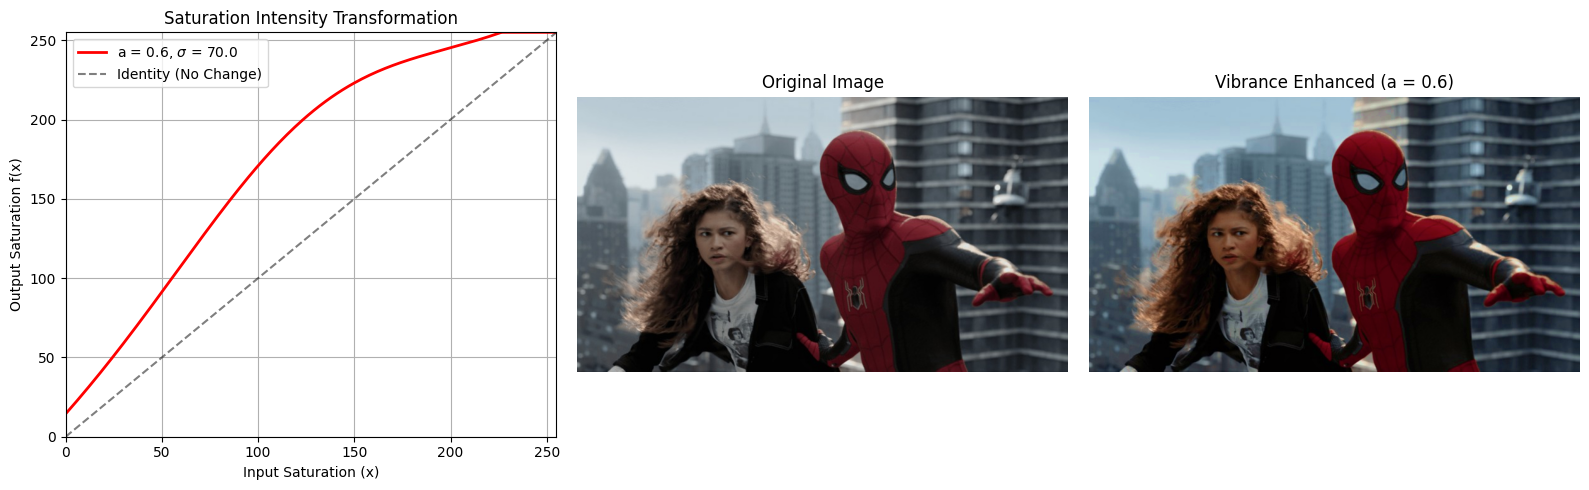

Reported value of parameter a: 0.6


In [11]:
img_path = 'spidy.jpeg'  

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Cannot find '{img_path}'. Ensure the file is in your working directory.")

img_bgr = cv.imread(img_path)

# 2. Split into Hue, Saturation, and Value planes
hsv_img = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv_img)

# 3. Apply transformation to Saturation plane
a_val = 0.6  # Tune 'a' in range [0, 1] for visual output
sigma_val = 70.0

S_enhanced = enhance_vibrance(S, a=a_val, sigma=sigma_val)

# 4. Recombine planes and convert back to BGR/RGB
hsv_enhanced = cv.merge([H, S_enhanced, V])
result_bgr = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2BGR)

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
result_rgb = cv.cvtColor(result_bgr, cv.COLOR_BGR2RGB)

# 5. Visualization & Outputs
fig = plt.figure(figsize=(16, 5))

# Plot 1: Intensity Transformation Curve
ax1 = fig.add_subplot(1, 3, 1)
x_vals = np.arange(0, 256, dtype=np.float32)
y_vals = np.minimum(x_vals + a_val * 128.0 * np.exp(-((x_vals - 128.0)**2) / (2.0 * (sigma_val**2))), 255.0)
ax1.plot(x_vals, y_vals, 'r-', linewidth=2, label=f'a = {a_val}, $\sigma$ = {sigma_val}')
ax1.plot([0, 255], [0, 255], 'k--', alpha=0.5, label='Identity (No Change)')
ax1.set_title('Saturation Intensity Transformation')
ax1.set_xlabel('Input Saturation (x)')
ax1.set_ylabel('Output Saturation f(x)')
ax1.set_xlim([0, 255])
ax1.set_ylim([0, 255])
ax1.legend()
ax1.grid(True)

# Plot 2: Original Image
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(img_rgb)
ax2.set_title('Original Image')
ax2.axis('off')

# Plot 3: Enhanced Image
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(result_rgb)
ax3.set_title(f'Vibrance Enhanced (a = {a_val})')
ax3.axis('off')

plt.tight_layout()
plt.show()

# Report selected parameter
print(f"Reported value of parameter a: {a_val}")

# Question 05

## Histogram Equalization for Contrast Enhancement

Histogram equalization enhances image contrast by redistributing pixel intensities across the full grayscale dynamic range (**0–255**). This process spreads out concentrated gray-level frequencies, making details in low-contrast regions more visible.

### CDF Mapping Algorithm

The transformation is based on the **Cumulative Distribution Function (CDF)** of the image histogram. Each input intensity value is mapped using:

$$
T(r) = \text{round}\left(
\frac{\text{CDF}(r)-\text{CDF}_{\min}}
{(M \times N)-\text{CDF}_{\min}}
\times 255
\right)
$$

where:

- **\(r\)** = input pixel intensity.
- **\(\text{CDF}(r)\)** = cumulative distribution function at intensity \(r\).
- **\(\text{CDF}_{\min}\)** = first non-zero value in the CDF.
- **\(M \times N\)** = total number of pixels in the image.
- **255** = maximum grayscale intensity.

### Histogram Analysis

The original image histogram is concentrated within a limited range of gray levels, indicating a **low dynamic range** and reduced image contrast.

After histogram equalization, the histogram is redistributed across the entire **0–255** intensity range. This increases the overall dynamic range, enhances local image details, and improves global contrast, making anatomical structures more distinguishable.

In [14]:
def custom_histogram_equalization(im):
    
    # 1. Calculate intensity frequencies (histogram)
    hist = np.zeros(256, dtype=np.int32)
    for pixel in im.ravel():
        hist[pixel] += 1

    # 2. Compute Cumulative Distribution Function (CDF)
    cdf = np.cumsum(hist)

    # 3. Find minimum non-zero CDF value
    cdf_min = cdf[cdf > 0].min()
    total_pixels = im.shape[0] * im.shape[1]

    # 4. Compute equalized mapping table T(r)
    # Scale values between 0 and 255
    lut = np.round(((cdf - cdf_min) / (total_pixels - cdf_min)) * 255).astype(np.uint8)

    # 5. Map original pixels to new equalized intensities using lookup table
    equalized_im = lut[im]

    # Compute equalized histogram for visualization
    eq_hist = np.zeros(256, dtype=np.int32)
    for pixel in equalized_im.ravel():
        eq_hist[pixel] += 1

    return equalized_im, hist, eq_hist

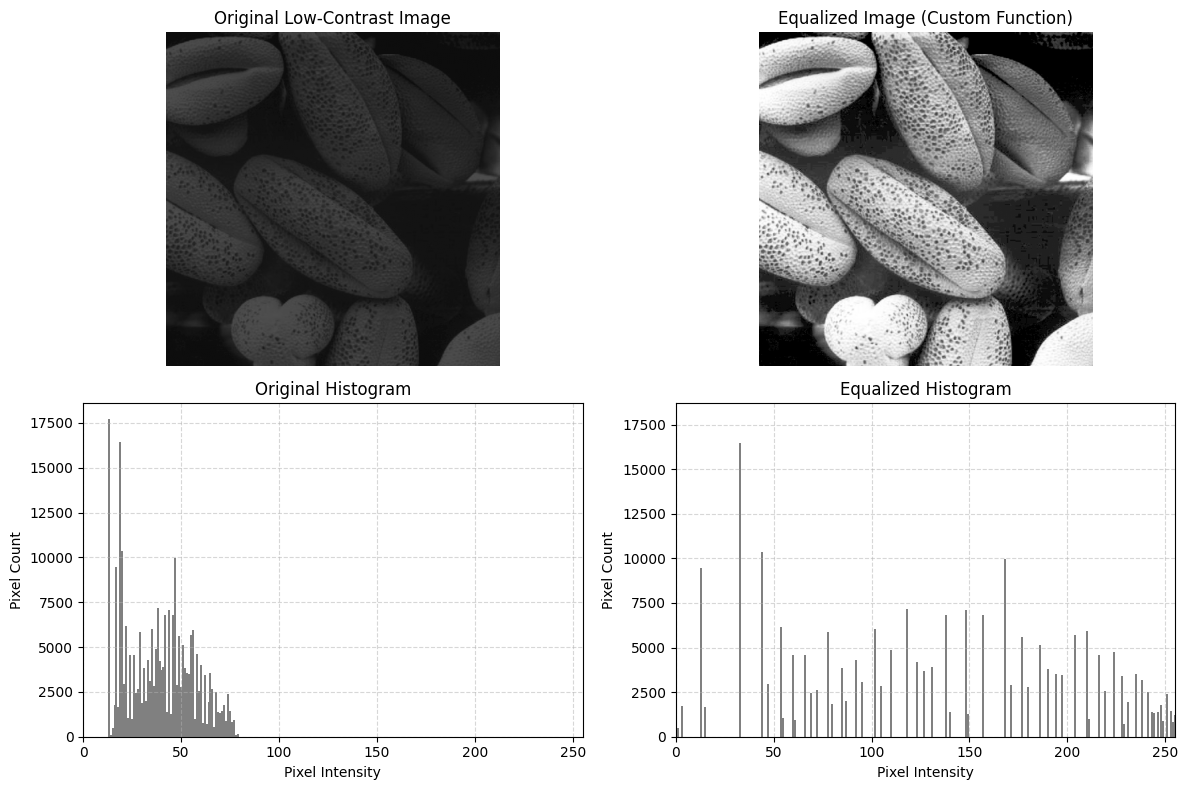

In [13]:
img_path = 'shells.tif'  

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Cannot find '{img_path}'. Ensure the file is in your working directory.")

img_gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

# --- 2. Run Manual Equalization ---
eq_img, orig_hist, eq_hist = custom_histogram_equalization(img_gray)

# --- 3. Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original Image
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Low-Contrast Image')
axes[0, 0].axis('off')

# Equalized Image
axes[0, 1].imshow(eq_img, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Equalized Image (Custom Function)')
axes[0, 1].axis('off')

# Original Histogram
axes[1, 0].bar(range(256), orig_hist, width=1, color='gray')
axes[1, 0].set_title('Original Histogram')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Pixel Count')
axes[1, 0].set_xlim([0, 255])
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Equalized Histogram
axes[1, 1].bar(range(256), eq_hist, width=1, color='gray')
axes[1, 1].set_title('Equalized Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Pixel Count')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Question 06

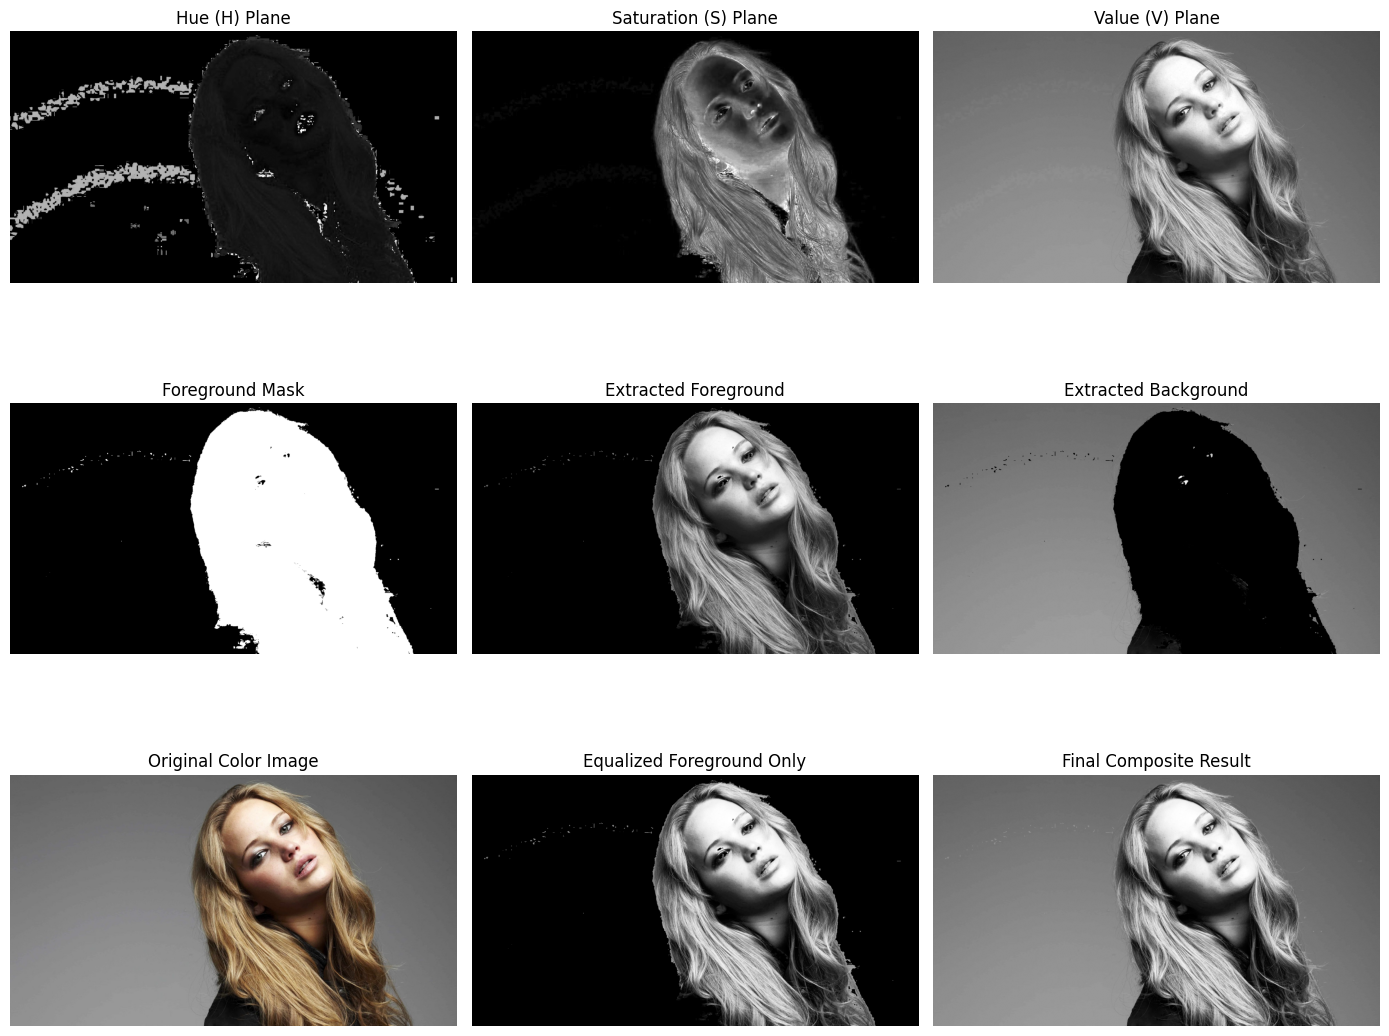

In [4]:
img_path = 'jeniffer.jpeg'

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Cannot find '{img_path}'. Check your working directory.")

img_bgr = cv.imread(img_path)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

# (a) Split HSV planes
hsv_img = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv_img)

# (b) Threshold plane to extract binary mask
_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)

# (c) Obtain foreground only
fg = cv.bitwise_and(img_gray, img_gray, mask=mask)

# (d) Compute histogram and cumulative sum over masked foreground pixels
fg_pixels = fg[mask > 0]
hist, _ = np.histogram(fg_pixels, bins=256, range=[0, 256])
cdf = np.cumsum(hist)

# (e) Equalize foreground using CDF formula
cdf_min = cdf[cdf > 0].min()
total_fg_pixels = fg_pixels.size

lut = np.round(((cdf - cdf_min) / (total_fg_pixels - cdf_min)) * 255).astype(np.uint8)
lut[0] = 0  # Keep background index zeroed

fg_equalized = lut[fg]
fg_equalized = cv.bitwise_and(fg_equalized, fg_equalized, mask=mask)

# (f) Combine background and equalized foreground
bg_mask = cv.bitwise_not(mask)
bg = cv.bitwise_and(img_gray, img_gray, mask=bg_mask)
result = cv.add(bg, fg_equalized)

# --- Visualization ---
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

# Row 1: HSV Planes
axes[0, 0].imshow(H, cmap='gray')
axes[0, 0].set_title('Hue (H) Plane')
axes[0, 0].axis('off')

axes[0, 1].imshow(S, cmap='gray')
axes[0, 1].set_title('Saturation (S) Plane')
axes[0, 1].axis('off')

axes[0, 2].imshow(V, cmap='gray')
axes[0, 2].set_title('Value (V) Plane')
axes[0, 2].axis('off')

# Row 2: Mask, Extracted FG, Background
axes[1, 0].imshow(mask, cmap='gray')
axes[1, 0].set_title('Foreground Mask')
axes[1, 0].axis('off')

axes[1, 1].imshow(fg, cmap='gray')
axes[1, 1].set_title('Extracted Foreground')
axes[1, 1].axis('off')

axes[1, 2].imshow(bg, cmap='gray')
axes[1, 2].set_title('Extracted Background')
axes[1, 2].axis('off')

# Row 3: Final Outputs
axes[2, 0].imshow(img_rgb)
axes[2, 0].set_title('Original Color Image')
axes[2, 0].axis('off')

axes[2, 1].imshow(fg_equalized, cmap='gray')
axes[2, 1].set_title('Equalized Foreground Only')
axes[2, 1].axis('off')

axes[2, 2].imshow(result, cmap='gray')
axes[2, 2].set_title('Final Composite Result')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()